Sofia Anaya Palafox

738594

Ingeniería FINANCIERA

In [15]:
import yfinance as yf
import matplotlib.pyplot as plt

In [16]:
ticker = ['AAPL']
price = yf.download(ticker, start = "2026-03-22", end= "2026-09-22")

/tmp/ipykernel_1295/2919704148.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download(ticker, start = "2026-03-22", end= "2026-09-22")
[*********************100%***********************]  1 of 1 completed


In [25]:
# Mostrar información general del DataFrame
print("--- Información del DataFrame ---")
display(price.info())

# Mostrar estadísticas descriptivas
print("\n--- Estadísticas Descriptivas ---")
display(price.describe())

--- Información del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 126 entries, 2026-03-23 to 2026-09-21
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   126 non-null    float64
 1   (High, AAPL)    126 non-null    float64
 2   (Low, AAPL)     126 non-null    float64
 3   (Open, AAPL)    126 non-null    float64
 4   (Volume, AAPL)  126 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 5.9 KB


None


--- Estadísticas Descriptivas ---


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,126.000000,126.000000,126.000000,126.000000,1.260000e+02
mean,298.901410,301.896807,295.243295,298.172311,5.027849e+07
std,24.899430,24.936182,24.469716,24.606713,2.485258e+07
min,246.190659,250.423096,245.072643,247.468376,2.586980e+07
25%,282.006783,286.910475,276.474115,279.603307,3.874555e+07
50%,305.085007,307.960007,300.985428,304.823681,4.487450e+07
75%,315.018333,317.011596,310.346675,314.353900,5.300975e+07
max,339.786926,344.273097,337.059318,339.736982,2.617755e+08


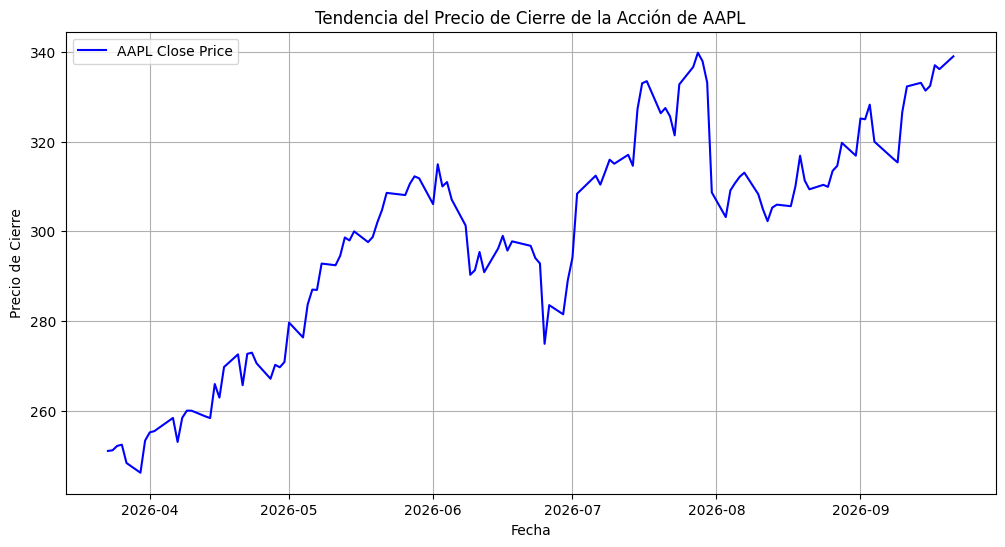

In [27]:
# Visualizar la tendencia del precio de cierre de AAPL
plt.figure(figsize=(12, 6))
plt.plot(price.index, price['Close']['AAPL'], label='AAPL Close Price', color='blue')
plt.title('Tendencia del Precio de Cierre de la Acción de AAPL')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.grid(True)
plt.legend()
plt.show()

In [28]:
import numpy as np

# Determinar S0 (precio inicial) y St (precio de vencimiento)
# S0 es el precio de cierre en la fecha de inicio del periodo de datos (2026-03-23)
# St es el precio de cierre en la fecha de fin del periodo de datos (2026-09-21)
S0_historical = price.loc['2026-03-23']['Close']['AAPL']
St_historical = price.loc['2026-09-21']['Close']['AAPL']

# El precio de ejercicio (K) es igual al precio inicial (S0)
K_historical = S0_historical

print(f"Precio Inicial (S0) el 23 de marzo de 2026: {S0_historical:.2f}")
print(f"Precio de Vencimiento (St) el 21 de septiembre de 2026: {St_historical:.2f}")
print(f"Precio de Ejercicio (K): {K_historical:.2f}")

# Calcular la ganancia de la opción Call
call_payoff_historical = max(0, St_historical - K_historical)

# Calcular la ganancia de la opción Put
put_payoff_historical = max(0, K_historical - St_historical)

print(f"\nGanancia de la Opción Call (max(0, St - K)): {call_payoff_historical:.2f}")
print(f"Ganancia de la Opción Put (max(0, K - St)): {put_payoff_historical:.2f}")

Precio Inicial (S0) el 23 de marzo de 2026: 251.04
Precio de Vencimiento (St) el 21 de septiembre de 2026: 338.98
Precio de Ejercicio (K): 251.04

Ganancia de la Opción Call (max(0, St - K)): 87.94
Ganancia de la Opción Put (max(0, K - St)): 0.00


## Simulación de Opciones (Call y Put: Europea, Asiática, Lookback)


In [29]:
# Importar librerías necesarias
import numpy as np
import pandas as pd

# Parámetros de la simulación
S0 = price['Close']['AAPL'].iloc[-1] # Precio actual de la acción (último precio de cierre disponible)
K = S0 # Precio de ejercicio (strike price) igual al precio inicial
T = 0.5 # Tiempo hasta el vencimiento en años (6 meses)
r = 0.05 # Tasa de interés libre de riesgo anualizada
sigma = annual_volatility # Volatilidad anualizada (calculada previamente)
num_simulations = 10000 # Número de caminos de Monte Carlo a simular
num_steps = 252 # Número de pasos de tiempo (días de negociación en un año)

dt = T / num_steps # Intervalo de tiempo para cada paso

print(f"Parámetros de la simulación:")
print(f"  S0 (Precio Inicial): {S0:.2f}")
print(f"  K (Precio de Ejercicio): {K:.2f}")
print(f"  T (Tiempo a Vencimiento): {T} años")
print(f"  r (Tasa Libre de Riesgo): {r*100:.2f}%")
print(f"  sigma (Volatilidad): {sigma*100:.2f}%")
print(f"  num_simulations (Número de Simulaciones): {num_simulations}")
print(f"  num_steps (Número de Pasos): {num_steps}")

Parámetros de la simulación:
  S0 (Precio Inicial): 338.98
  K (Precio de Ejercicio): 338.98
  T (Tiempo a Vencimiento): 0.5 años
  r (Tasa Libre de Riesgo): 5.00%
  sigma (Volatilidad): 27.67%
  num_simulations (Número de Simulaciones): 10000
  num_steps (Número de Pasos): 252


## Cálculo de Payoffs Históricos de Opciones (Solo con Datos Descargados)

23 de marzo de 2026 al 21 de septiembre de 2026.


In [35]:
# Definir las fechas de inicio y fin para el cálculo histórico
start_date = '2026-03-23'
end_date = '2026-09-21'

# Extraer los precios de cierre para el período
historical_prices_period = price['Close']['AAPL'].loc[start_date:end_date]

# Determinar S0 y St del período histórico
S0_period = historical_prices_period.iloc[0]
St_period = historical_prices_period.iloc[-1]

# K es igual al precio inicial del período
K_period = S0_period

print(f"--- Parámetros Históricos para el Período {start_date} a {end_date} ---")
print(f"Precio Inicial del Período (S0_period): {S0_period:.2f}")
print(f"Precio Final del Período (St_period): {St_period:.2f}")
print(f"Precio de Ejercicio (K_period): {K_period:.2f}")

# 1. Opción Europea
call_payoff_european_hist = max(0, St_period - K_period)
put_payoff_european_hist = max(0, K_period - St_period)

print(f"\n--- Payoffs Históricos de Opción Europea ---")
print(f"Call Europea: {call_payoff_european_hist:.2f}")
print(f"Put Europea: {put_payoff_european_hist:.2f}")

# 2. Opción Asiática
# El precio promedio se calcula sobre todos los precios de cierre en el período
average_price_hist = historical_prices_period.mean()
call_payoff_asian_hist = max(0, average_price_hist - K_period)
put_payoff_asian_hist = max(0, K_period - average_price_hist)

print(f"\n--- Payoffs Históricos de Opción Asiática ---")
print(f"Precio Promedio Histórico del Período: {average_price_hist:.2f}")
print(f"Call Asiática: {call_payoff_asian_hist:.2f}")
print(f"Put Asiática: {put_payoff_asian_hist:.2f}")

# 3. Opción Lookback
# El precio máximo/mínimo se calcula sobre todos los precios de cierre en el período
max_price_hist = historical_prices_period.max()
min_price_hist = historical_prices_period.min()

call_payoff_lookback_hist = max(0, max_price_hist - K_period)
put_payoff_lookback_hist = max(0, K_period - min_price_hist)

print(f"\n--- Payoffs Históricos de Opción Lookback ---")
print(f"Precio Máximo Histórico del Período: {max_price_hist:.2f}")
print(f"Precio Mínimo Histórico del Período: {min_price_hist:.2f}")
print(f"Call Lookback: {call_payoff_lookback_hist:.2f}")
print(f"Put Lookback: {put_payoff_lookback_hist:.2f}")

--- Parámetros Históricos para el Período 2026-03-23 a 2026-09-21 ---
Precio Inicial del Período (S0_period): 251.04
Precio Final del Período (St_period): 338.98
Precio de Ejercicio (K_period): 251.04

--- Payoffs Históricos de Opción Europea ---
Call Europea: 87.94
Put Europea: 0.00

--- Payoffs Históricos de Opción Asiática ---
Precio Promedio Histórico del Período: 298.90
Call Asiática: 47.86
Put Asiática: 0.00

--- Payoffs Históricos de Opción Lookback ---
Precio Máximo Histórico del Período: 339.79
Precio Mínimo Histórico del Período: 246.19
Call Lookback: 88.74
Put Lookback: 4.85


## Predicción de Precios para los Próximos 6 Meses (23 de Mar. 2026 - 23 de Sep. 2026)


In [36]:
# 1. Descargar datos históricos para calcular mu y sigma
print("Descargando datos históricos de AAPL (2025-09-23 a 2026-03-23) para nuevos parámetros...")
historical_data_for_params = yf.download(ticker, start="2025-09-23", end="2026-03-24") # Incluye el 23 de marzo
display(historical_data_for_params.head())
display(historical_data_for_params.tail())

# 2. Calcular retornos logarítmicos para este nuevo período
new_log_returns = np.log(historical_data_for_params['Close']['AAPL'] / historical_data_for_params['Close']['AAPL'].shift(1)).dropna()

# 3. Calcular nueva mu (drif anualizado) y sigma (volatilidad anualizada)
daily_log_returns_mean_new = new_log_returns.mean()
daily_log_returns_std_new = new_log_returns.std()

new_annual_log_returns_mean = daily_log_returns_mean_new * 252 # 252 días de trading al año
new_annual_volatility = daily_log_returns_std_new * np.sqrt(252)

print(f"\nNuevos Parámetros Calculados:")
print(f"  Nueva mu anualizada: {new_annual_log_returns_mean:.4f}")
print(f"  Nueva sigma anualizada: {new_annual_volatility:.4f}")

/tmp/ipykernel_1295/4259429672.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical_data_for_params = yf.download(ticker, start="2025-09-23", end="2026-03-24") # Incluye el 23 de marzo
[*********************100%***********************]  1 of 1 completed

Descargando datos históricos de AAPL (2025-09-23 a 2026-03-23) para nuevos parámetros...


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-09-23,253.493591,256.392885,252.646729,254.938267,60275200
2025-09-24,251.381409,254.798793,250.116078,254.280703,42303700
2025-09-25,255.924622,256.223536,250.783624,252.278103,55202100
2025-09-26,254.519806,256.651929,252.845981,253.164811,46076300
2025-09-29,253.493591,254.061501,252.078819,253.623118,40127700


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-03-17,253.777115,254.675521,251.730764,252.509388,32361600
2026-03-18,249.494766,254.485859,248.556438,252.179977,35757900
2026-03-19,248.516525,251.381408,246.859479,248.955729,34864100
2026-03-20,247.548233,248.756069,245.561773,247.538241,88331100
2026-03-23,251.042007,254.146468,249.834156,253.517585,40546100



Nuevos Parámetros Calculados:
  Nueva mu anualizada: -0.0198
  Nueva sigma anualizada: 0.2116


### Configuración de la Nueva Simulación de Monte Carlo

In [41]:
# Parámetros de la nueva simulación
S0_new_simulation = historical_data_for_params['Close']['AAPL'].iloc[-1] # Último precio de cierre del período de cálculo de parámetros
K_new_simulation = S0_new_simulation # Precio de ejercicio igual al precio inicial de la simulación
T_new_simulation = 0.5 # 6 meses = 0.5 años
r_new_simulation = 0.05 # Tasa de interés libre de riesgo (mantenemos la anterior)
num_simulations_new = 10000 # M=10000
num_steps_new = 126 # n=126

dt_new = T_new_simulation / num_steps_new

### Generación de Caminos del Precio de la Acción para la Predicción

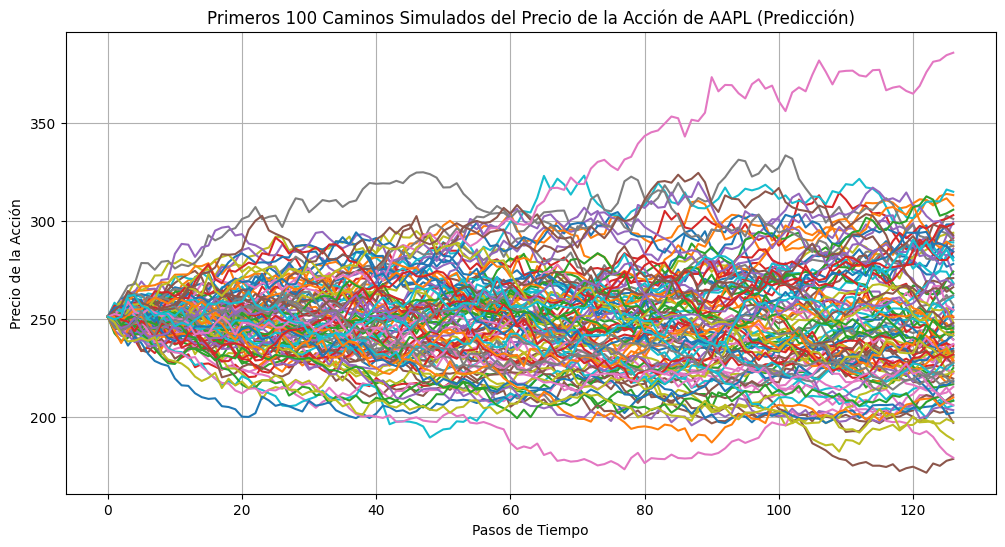

In [38]:
np.random.seed(43) # Nueva semilla para esta simulación

# Generar ruido aleatorio
z_new = np.random.normal(0, 1, size=(num_simulations_new, num_steps_new))

# Crear array para almacenar los caminos de precios
s_paths_new = np.zeros((num_simulations_new, num_steps_new + 1))
s_paths_new[:, 0] = S0_new_simulation

# Simular los caminos de precios usando Movimiento Browniano Geométrico
for t_step in range(1, num_steps_new + 1):
    s_paths_new[:, t_step] = s_paths_new[:, t_step-1] * np.exp((new_annual_log_returns_mean - 0.5 * new_annual_volatility**2) * dt_new + new_annual_volatility * np.sqrt(dt_new) * z_new[:, t_step-1])

# Visualizar algunos caminos simulados para verificar la predicción
plt.figure(figsize=(12, 6))
plt.plot(s_paths_new[:100, :].T) # Graficar los primeros 100 caminos
plt.title('Primeros 100 Caminos Simulados del Precio de la Acción de AAPL (Predicción)')
plt.xlabel('Pasos de Tiempo')
plt.ylabel('Precio de la Acción')
plt.grid(True)
plt.show()

### Cálculo de Opciones (Call y Put: Europea, Asiática, Lookback) para la Predicción



In [39]:
# 1. Opciones Europeas
call_payoffs_euro_pred = np.maximum(0, s_paths_new[:, -1] - K_new_simulation)
european_call_price_pred = np.exp(-r_new_simulation * T_new_simulation) * np.mean(call_payoffs_euro_pred)

put_payoffs_euro_pred = np.maximum(0, K_new_simulation - s_paths_new[:, -1])
european_put_price_pred = np.exp(-r_new_simulation * T_new_simulation) * np.mean(put_payoffs_euro_pred)

print(f"\n--- Precios de Opciones Europeas (Predicción) ---")
print(f"  Call Europea: {european_call_price_pred:.2f}")
print(f"  Put Europea: {european_put_price_pred:.2f}")

# 2. Opciones Asiáticas
average_prices_pred = np.mean(s_paths_new[:, 1:], axis=1)
call_payoffs_asian_pred = np.maximum(0, average_prices_pred - K_new_simulation)
asian_call_price_pred = np.exp(-r_new_simulation * T_new_simulation) * np.mean(call_payoffs_asian_pred)

put_payoffs_asian_pred = np.maximum(0, K_new_simulation - average_prices_pred)
asian_put_price_pred = np.exp(-r_new_simulation * T_new_simulation) * np.mean(put_payoffs_asian_pred)

print(f"\n--- Precios de Opciones Asiáticas (Predicción) ---")
print(f"  Call Asiática: {asian_call_price_pred:.2f}")
print(f"  Put Asiática: {asian_put_price_pred:.2f}")

# 3. Opciones Lookback
max_prices_pred = np.max(s_paths_new[:, 1:], axis=1)
min_prices_pred = np.min(s_paths_new[:, 1:], axis=1)

call_payoffs_lookback_pred = np.maximum(0, max_prices_pred - K_new_simulation)
lookback_call_price_pred = np.exp(-r_new_simulation * T_new_simulation) * np.mean(call_payoffs_lookback_pred)

put_payoffs_lookback_pred = np.maximum(0, K_new_simulation - min_prices_pred)
lookback_put_price_pred = np.exp(-r_new_simulation * T_new_simulation) * np.mean(put_payoffs_lookback_pred)

print(f"\n--- Precios de Opciones Lookback (Predicción) ---")
print(f"  Call Lookback: {lookback_call_price_pred:.2f}")
print(f"  Put Lookback: {lookback_put_price_pred:.2f}")


--- Precios de Opciones Europeas (Predicción) ---
  Call Europea: 13.31
  Put Europea: 15.76

--- Precios de Opciones Asiáticas (Predicción) ---
  Call Asiática: 7.89
  Put Asiática: 9.05

--- Precios de Opciones Lookback (Predicción) ---
  Call Lookback: 27.23
  Put Lookback: 27.20


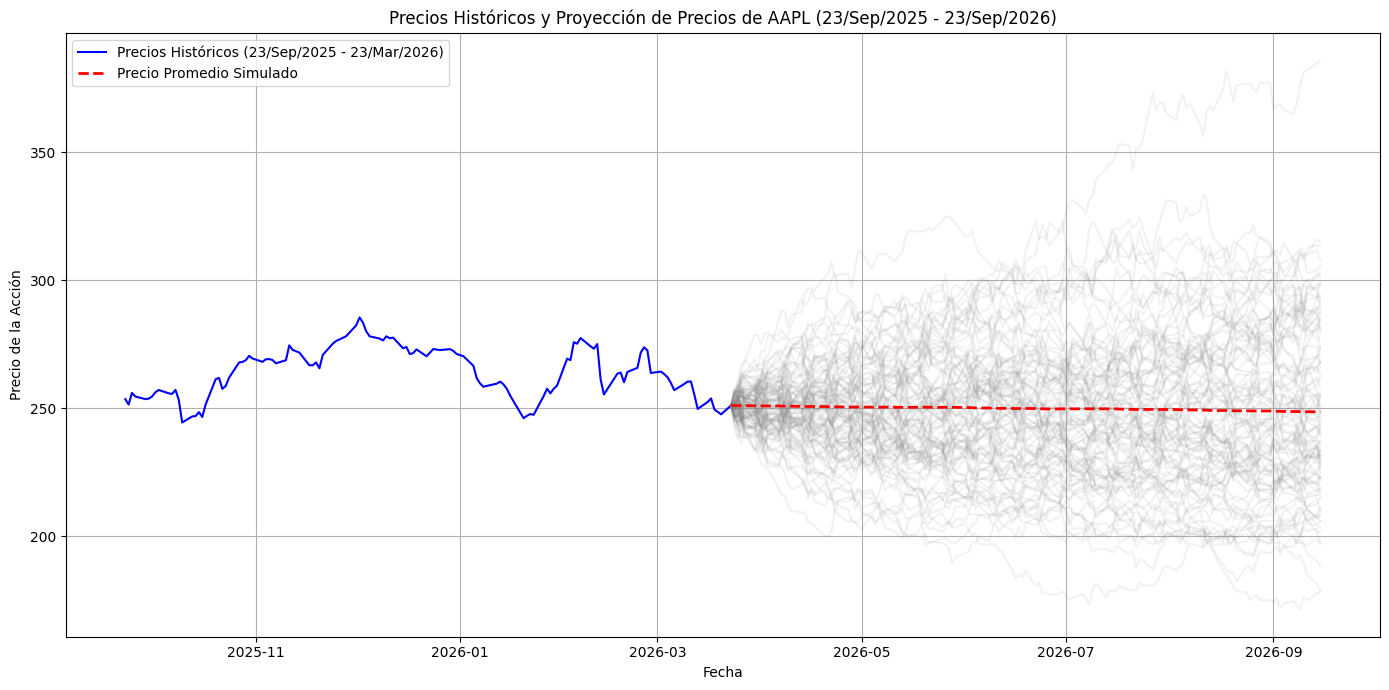

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.figure(figsize=(14, 7))

# Obtener los precios históricos del DataFrame `historical_data_for_params`
historical_prices = historical_data_for_params['Close']['AAPL']

# Trazar los precios históricos
plt.plot(historical_prices.index, historical_prices, label='Precios Históricos (23/Sep/2025 - 23/Mar/2026)', color='blue')

# Generar fechas futuras para la simulación
# La simulación comienza desde la última fecha histórica (23/Mar/2026)
last_historical_date = historical_prices.index[-1]
# Creamos un rango de fechas que incluye la última fecha histórica y se extiende
# por el número de pasos de la simulación (num_steps_new + 1 puntos en total).
# Usamos 'B' para frecuencia de días hábiles.
future_dates = pd.date_range(start=last_historical_date, periods=num_steps_new + 1, freq='B')

# Trazar un subconjunto de caminos simulados (por ejemplo, los primeros 100)
num_paths_to_plot = 100
for i in range(num_paths_to_plot):
    plt.plot(future_dates, s_paths_new[i, :], color='gray', alpha=0.1) # alpha bajo para mostrar densidad

# Trazar el promedio de los caminos simulados
mean_simulated_path = np.mean(s_paths_new, axis=0)
plt.plot(future_dates, mean_simulated_path, label='Precio Promedio Simulado', color='red', linestyle='--', linewidth=2)

plt.title('Precios Históricos y Proyección de Precios de AAPL (23/Sep/2025 - 23/Sep/2026)')
plt.xlabel('Fecha')
plt.ylabel('Precio de la Acción')
plt.legend()
plt.grid(True)
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()